# Midterm preparation

## Domain coloring

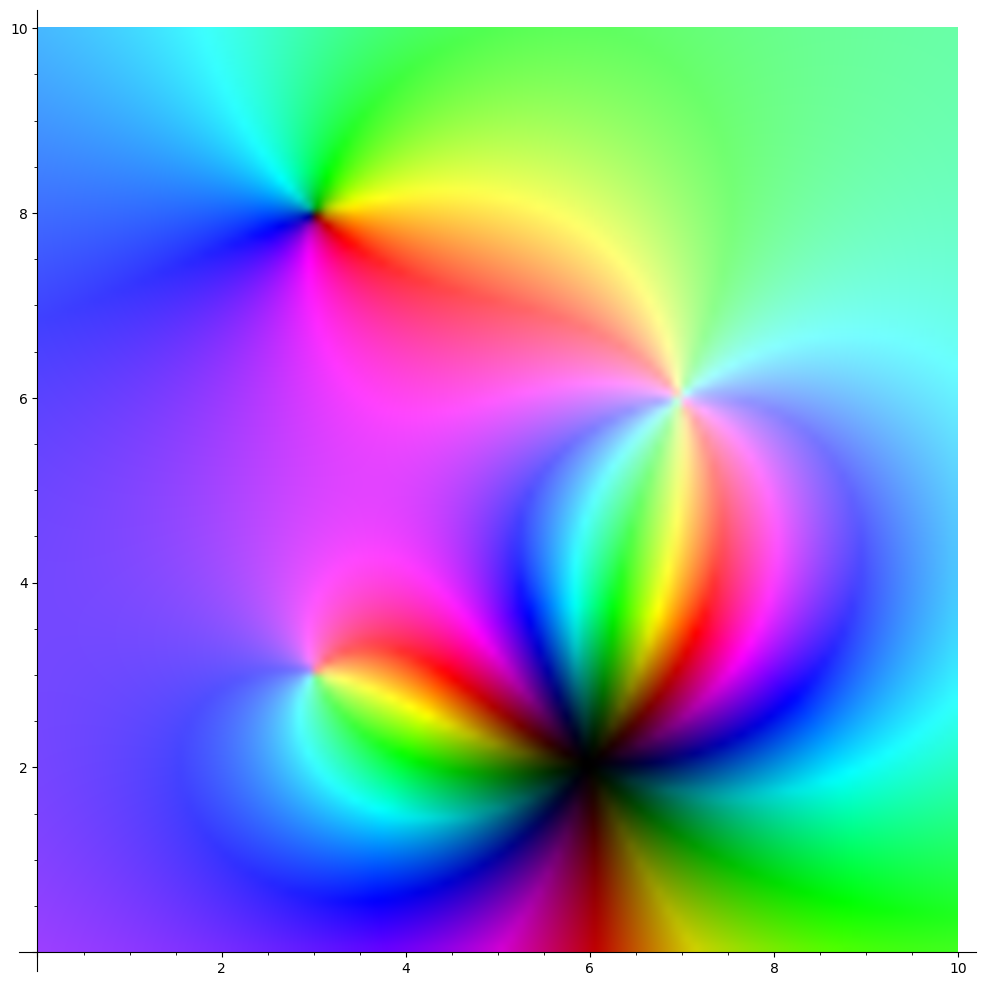

In [138]:
var('z')
CP = complex_plot( 2 * i * (z - 3 - 8*i) * (z - 6 - 2*i)^3 / (z - 7 - 6*i)^2 / (z - 3 - 3*i), (0, 10), (0, 10))
CP.show(figsize=(10, 10))

In [139]:
CP.save_image("dc1.png", figsize=(10, 10))

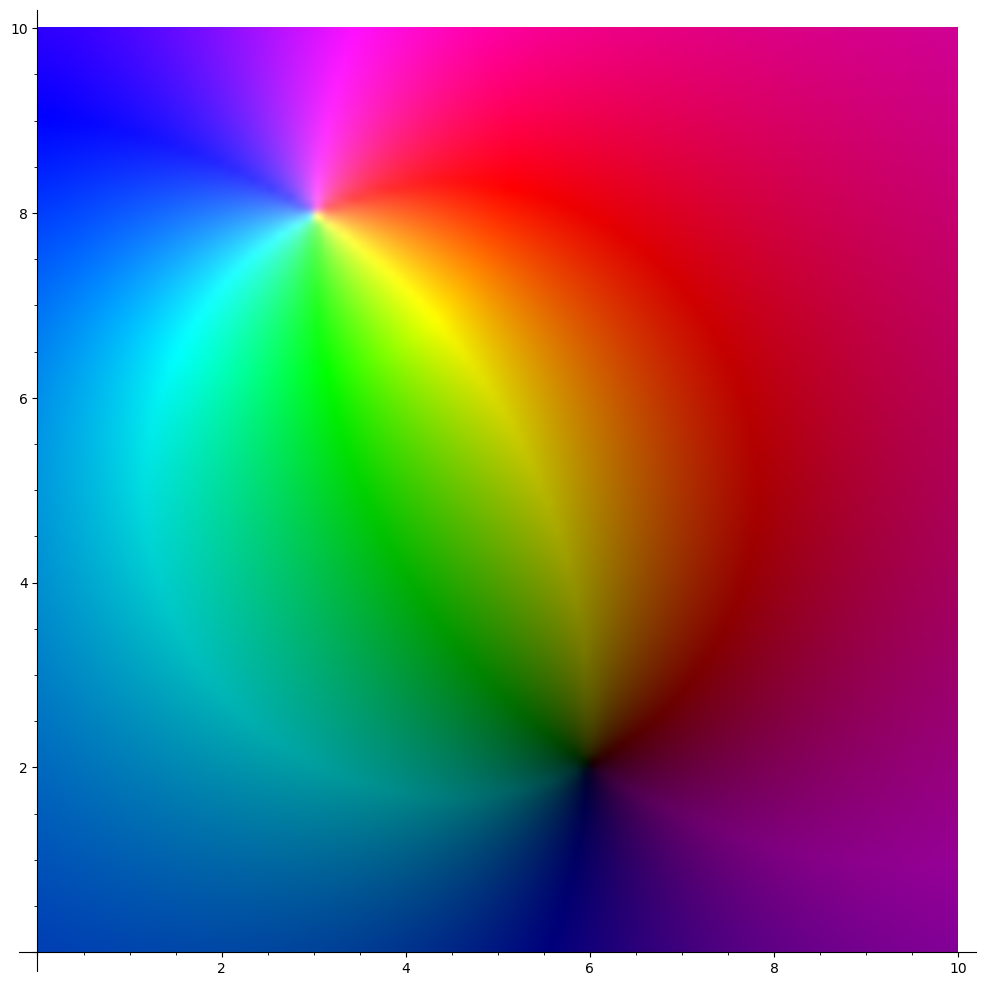

In [134]:
var('z')
CP = complex_plot( - i * (z - 6 - 2*i) / (z - 3 - 8*i), (0, 10), (0, 10))
CP.show(figsize=(10, 10))

In [163]:
- i * (z - 6 - 2*i) / (z - 3 - 8*i) == (2 - 6*i + i * z) / (3 + 8*i - z)

(-I*z + 6*I - 2)/(z - 8*I - 3) == -(I*z - 6*I + 2)/(z - 8*I - 3)

In [164]:
bool(_)

True

In [ ]:
CP.save_image("dc2.png", figsize=(10, 10))

In [146]:
from PIL import Image

# read dc1.png and make it 50% white
img = Image.open("dc1.png").convert("RGB")
white = Image.new("RGB", img.size, "white")
out = Image.blend(img, white, 0.8)
out.save("dc3.png")

## Zeta

In [ ]:
zeta(5 + 5*i).n()

0.973819242554574 + 0.0119825174357425*I

In [172]:
acc = 0.
for j in range(1, 35):
    acc += 1 / j^(5. + 5.*i)
acc

0.973819135647096 + 0.0119824904644554*I

## Q function

In [157]:
# half circle
m = 200
acc = 0
for j in range(m):
    z0 = 2. * i + -i * exp(n(i * pi * j / m))
    z1 = 2. * i + -i * exp(n(i * pi * (j+.5) / m))
    z2 = 2. * i + -i * exp(n(i * pi * (j+1) / m))
    dz = z2 - z0
    # print(z1.n())
    acc += (exp(z1^2) * dz).n()
acc

7.48988883609615e-18 + 0.139393122967427*I

In [159]:
# straight line
m = 200
acc = 0
for j in range(m):
    z0 = i + 2 * i * j / m
    z1 = i + 2 * i * (j + 0.5) / m
    z2 = i + 2 * i * (j + 1) / m
    dz = z2 - z0
    # print(z1.n())
    acc += (exp(z1^2) * dz).n()
acc

0.139380152852177*I

In [160]:
# Q function
(sqrt(pi/4) * (erf(3) - erf(1))).n()

0.139383215447094

## Numerical derivative

In [174]:
f(z) = cos(sin(cos(sin(cos(sin(z))))))
f.taylor(z, 0, 2)

z |--> -1/2*z^2*cos(1)*cos(cos(sin(1)))*sin(sin(1))*sin(sin(cos(sin(1)))) + cos(sin(cos(sin(1))))

In [175]:
f.diff(z, z)(0)

-cos(1)*cos(cos(sin(1)))*sin(sin(1))*sin(sin(cos(sin(1))))

In [176]:
_.n()

-0.183520487021611

In [179]:
(f(0.001) - 2*f(0) + f(0.001)).n() * 1e6

-0.183520465713016

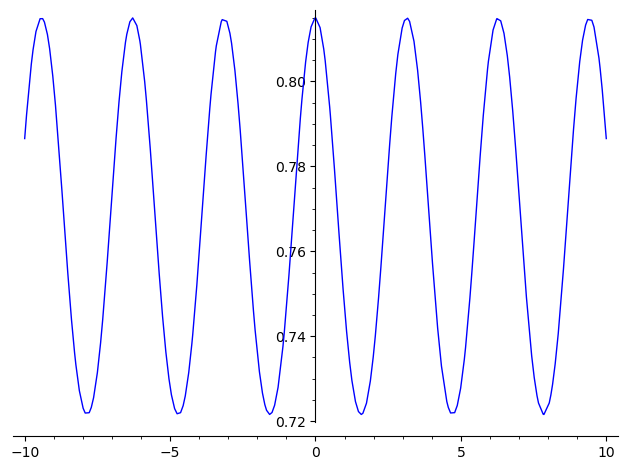

In [90]:
f.plot(-10, 10)

## Find roots

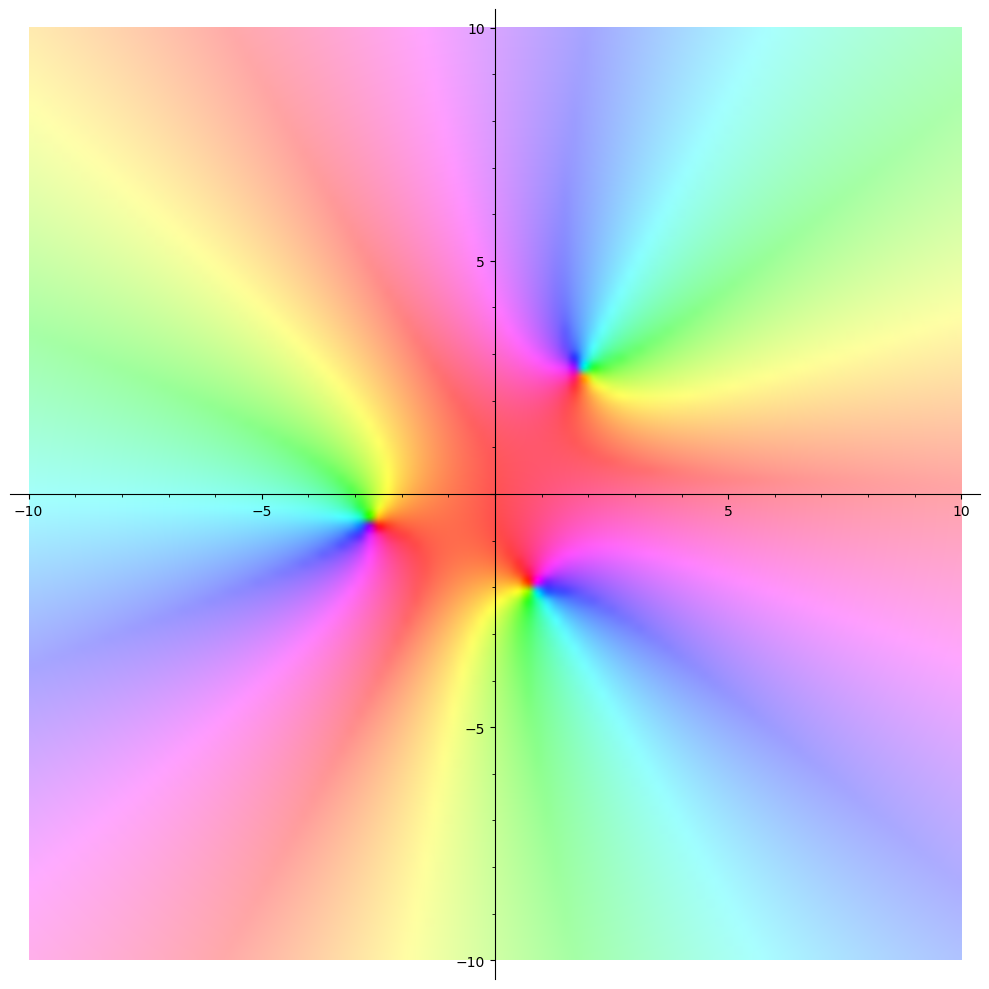

In [100]:
var('z')
complex_plot( z^3 - 5*i*z + 20, (-10, 10), (-10, 10)).show(figsize=(10, 10))

In [102]:
rr = (z^3 - 5*i*z + 20).roots()
rr

[(-1/2*(5/3*sqrt(5/3*I + 36) - 10)^(1/3)*(I*sqrt(3) + 1) - 5/6*(sqrt(3) + I)/(5/3*sqrt(5/3*I + 36) - 10)^(1/3),
  1),
 (-1/2*(5/3*sqrt(5/3*I + 36) - 10)^(1/3)*(-I*sqrt(3) + 1) + 5/6*(sqrt(3) - I)/(5/3*sqrt(5/3*I + 36) - 10)^(1/3),
  1),
 ((5/3*sqrt(5/3*I + 36) - 10)^(1/3) + 5/3*I/(5/3*sqrt(5/3*I + 36) - 10)^(1/3),
  1)]

In [104]:
for r in rr:
    print(r[0].n())

-2.71694673326721 - 0.624427885641441*I
0.835834570814979 - 2.03663009971984*I
1.88111216245223 + 2.66105798536128*I


## Half circle integral

In [122]:
(cos(x)/(x^2 + sqrt(2))).integral(x, 0, oo).n()

0.402157609063181

In [180]:
2 * (cos(x)/(x^2 + sqrt(2))).integral(x, 0, oo)

1/2*2^(3/4)*pi*e^(-2^(1/4))

In [110]:
(cos(x)/(x^2 + sqrt(2))).integral(x, -oo, oo).n()

0.804315218126363

In [182]:
(2^(-1/4) * pi * exp(-2^(1/4))).n()

0.804315218126363

## Winding number

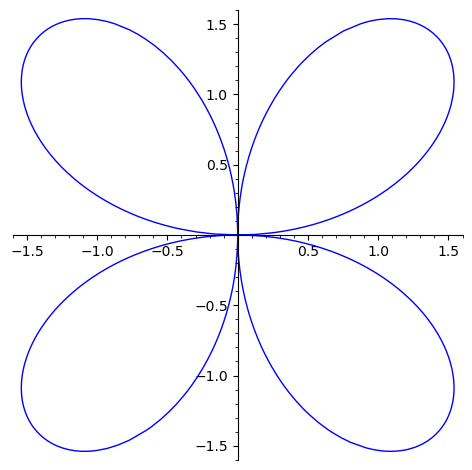

In [117]:
var('t')
r(t) = 2 * sin(2*t)
parametric_plot((r(t)*cos(t), r(t)*sin(t)), (t, 0, 2*pi))

In [ ]:
delta(t) = 2 * sin(2*t) * exp(i*t)



## Conformal map to wedge

In [165]:
f(z) = exp((2 + i) * z)

In [ ]:
[
    arg(f(1)).n(),
    arg(f(2)).n(),
    arg(f(i/2)).n(),
    arg(f(i)).n(),
]

[1.00000000000000, 2.00000000000000, 1.00000000000000, 2.00000000000000]

## Generating function

In [185]:
f(z) = z/(1 - 2*z)^2
f.taylor(z, 0, 5)

z |--> 80*z^5 + 32*z^4 + 12*z^3 + 4*z^2 + z